# 这里是为了查看时间漂流的影响

In [1]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import warnings
warnings.filterwarnings('ignore')
import numpy as np

from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import RandomSampler, SequentialSampler
from torch.optim.lr_scheduler import LambdaLR
import torch
from torch import nn
import torch.nn.functional as F
from torch import optim
from torch.autograd import Variable
from torch.cuda.amp import GradScaler, autocast

import tqdm
import pickle
import argparse
import random
import math
import os
import bisect
import numpy as np
import matplotlib.pyplot as plt
import dill


from sklearn.utils import shuffle


In [3]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu", 0)

In [3]:
data = np.load('./datasets/awf1_WFTFCaug.npz')

In [4]:
print(data.files)

['x_train', 'y_train']


In [5]:
key0 = data.files[0]
label = data.files[1]
keys = data[key0]
labels = data[label]
np.set_printoptions(threshold=np.inf)
print(keys[:1])
print(labels[0])

[[-1. -1.  1.  1.  1.  1. -1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1. -1.  1.
   1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1. -1. -1. -1. -1. -1.
  -1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. 

## 增强后的burst级别

In [2]:
def to_burst(trace, ignore_zero=True):
    burst = []

    prev = None
    cnt = 0

    for x in trace:
        x = int(x)

        if ignore_zero and x == 0:
            break          # 如果后面全是padding，可以直接break
            # continue     # 如果0可能出现在中间，就改成continue

        if prev is None:
            prev = x
            cnt = 1
        elif x == prev:
            cnt += 1
        else:
            burst.append(cnt if prev > 0 else -cnt)
            prev = x
            cnt = 1

    if cnt:
        burst.append(cnt if prev > 0 else -cnt)

    return burst

burst = to_burst(keys[0])
print(burst)
print(len(burst))

NameError: name 'keys' is not defined

In [8]:
burst = to_burst(keys[2])
print(burst)
print(len(burst))

[1, -2, 2, -21, 2, -16, 1, -1, 2, -1, 2, -33, 1, -4, 1, -17, 2, -2, 1, -1, 2, -14, 1, -22, 1, -4, 2, -6, 1, -32, 1, -19, 1, -11, 1, -34, 1, -19, 1, -11, 1, -5, 2, -5, 2, -13, 1, -10, 8, -1, 2, -1, 1, -2, 7, -3, 4, -23, 3, -1, 1, -19, 3, -2, 5, -4, 1, -1, 1, -6, 7, -7, 3, -19, 4, -5, 1, -6, 3, -6, 1, -1, 4, -9, 3, -39, 1, -11, 1, -11, 1, -38, 1, -10, 1, -16, 1, -1, 4, -8, 7, -2, 2, -23, 1, -13, 1, -20, 1, -44, 1, -11, 2, -55, 1, -12, 1, -24, 1, -30, 1, -20, 1, -33, 1, -11, 2, -1, 1, -40, 1, -6, 1, -13, 1, -6, 1, -23, 1, -36, 1, -20, 1, -12, 1, -27, 1, -23, 1, -5, 1, -5, 2, -43, 1, -3, 1, -54, 1, -4, 1, -36, 1, -7, 2, -25, 1, -3, 1, -8, 1, -17, 1, -33, 1, -34, 1, -23, 1, -9, 1, -42, 1, -24, 2, -23, 1, -26, 2, -22, 2, -33, 1, -17, 1, -27, 1, -23, 1, -8, 1, -22, 2, -31, 1, -27, 1, -32, 1, -15, 1, -19, 2, -32, 1, -30, 2, -32, 1, -21, 1, -12, 2, -1, 1, -5, 1, -1, 1, -21, 1, -4, 1, -6, 1, -24, 2, -2, 1, -8, 1, -24, 1, -16, 1, -5, 1, -23, 1, -24, 2, -28, 1, -30, 2, -29, 1, -7, 1, -31, 1, -3, 1

## 原始流量攻击打印

In [9]:
source_data = np.load('./datasets/proteus_train_sign.npz') 
print(source_data.files)
source_feature = source_data['X']
source_label = source_data['y']
print(source_label[0])
burst = to_burst(source_feature[0])
print(burst)
print(len(burst))
print(np.unique(source_label))

['X', 'y']
68.0
[1, -1, 1, -4, 1, -1, 1, -1, 1, -1, 1, -2, 1, -1, 1, -1, 1, -1, 1, -2, 1, -1, 2, -2, 1, -1, 1, -1, 1, -2, 1, -1, 3, -1, 1, -1, 1, -3, 1, -1, 1, -2, 1, -1, 1, -1, 1, -1, 1, -3, 2, -1, 1, -1, 1, -2, 1, -1, 1, -6, 1, -5, 6, -1, 1, -2, 4, -1, 1, -1, 2, -2, 1, -5, 2, -1, 1, -7, 3, -1, 1, -3, 1, -4, 1, -2, 1, -4, 1, -11, 1, -2, 1, -17, 1, -4, 1, -7, 1, -1, 1, -1, 1, -13, 1, -10, 1, -14, 1, -2, 1, -2, 7, -15, 1, -4, 2, -8, 1, -19, 1, -2, 3, -1, 1, -4, 1, -1, 1, -11, 1, -1, 1, -6, 1, -2, 3, -7, 1, -13, 1, -6, 2, -1, 1, -4, 1, -4, 1, -1, 1, -2, 1, -1, 1, -1, 1, -3, 1, -1, 2, -3, 2, -6, 2, -9, 1, -2, 1, -6, 1, -1, 3, -7, 1, -2, 1, -13, 1, -17, 1, -1, 1, -1, 1, -26, 2, -7, 1, -9, 1, -14, 1, -7, 1, -10, 1, -16, 1, -3, 1, -16, 2, -19, 1, -11, 1, -3, 1, -13, 1, -11, 1, -13, 1, -1, 1, -15, 1, -9, 1, -7, 1, -7, 1, -3, 1, -11, 1, -13, 1, -14, 1, -4, 1, -7, 1, -20, 1, -13, 1, -10, 1, -9, 1, -20, 1, -6, 1, -12, 1, -1, 1, -1, 1, -3, 1, -1, 1, -2, 1, -2, 1, -6, 1, -1, 1, -1, 1, -1, 1, -4, 2

## 目标域流量打印

In [3]:
target_data = np.load('./datasets/proteus_day90_sign.npz') 
target_feature = target_data['X']
target_label = target_data['y']
print(target_label[0])
burst = to_burst(target_feature[0])
print(burst)
print(len(burst))
print(np.unique(target_label))

0.0
[-1, 2, -3, 2, -1, 1, -1, 1, -1, 1, -1, 1, -7, 1, -3, 1, -2, 1, -1, 1, -4, 2, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -2, 1, -12, 1, -6, 2, -1, 1, -1, 1, -6, 1, -2, 1, -7, 1, -5, 1, -14, 1, -7, 1, -22, 1, -1, 1, -23, 1, -1, 1, -29, 1, -20, 1, -4, 1, -15, 1, -25, 1, -19, 2, -10, 1, -2, 2, -1, 1, -1, 1, -1, 2, -1, 1, -9, 1, -22, 1, -2, 3, -5, 1, -3, 1, -16, 1, -2, 1, -14, 1, -24, 1, -4, 1, -8, 1, -7, 1, -24, 1, -4, 1, -1, 1, -1, 1, -1, 2, -1, 2, -1, 2, -2, 3, -4, 1, -3, 1, -1, 2, -2, 1, -8, 1, -1, 1, -2, 1, -1, 2, -3, 1, -1, 1, -16, 1, -1, 1, -8, 1, -18, 2, -3, 1, -14, 1, -18, 4, -4, 1, -1, 1, -1, 1, -1, 1, -2, 1, -13, 1, -2, 1, -1, 1, -1, 1, -8, 1, -7, 1, -1, 2, -1, 1, -4, 1, -14, 1, -3, 1, -16, 2, -4, 1, -11, 1, -3, 2, -7, 1, -10, 1, -17, 1, -3, 1, -2, 1, -2, 2, -3, 2, -1, 2, -1, 1, -1, 1, -1, 1, -1, 1, -1, 2, -1, 1, -6, 1, -1, 4, -1, 6, -1, 1, -1, 1, -9, 1, -16, 1, -8, 1, -12, 1, -20, 1, -1, 1, -1, 1, -3, 1, -2, 1, -5, 7, -9, 1, -2, 2, -11, 2, -1, 1, -1, 1, -5, 1, -6, 1, -3, 1, -18, 1,

## 转化为频谱看看

In [6]:
## 正常得频谱z
# def trace_to_spectrum(trace, remove_padding=True, normalize=False):
#     """
#     将 ±1 序列转换为频谱。

#     Parameters
#     ----------
#     trace : array-like
#         输入的 ±1 序列，可包含尾部 0 padding。
#     remove_padding : bool
#         是否去除尾部 padding(0)。
#     normalize : bool
#         是否对幅值进行归一化。

#     Returns
#     -------
#     freq : np.ndarray
#         频率坐标（0~0.5，归一化频率）
#     spectrum : np.ndarray
#         单边幅值谱
#     """

#     trace = np.asarray(trace, dtype=np.float32)

#     if remove_padding:
#         trace = trace[trace != 0]

#     if len(trace) == 0:
#         raise ValueError("Trace is empty after removing padding.")

#     # FFT
#     fft = np.fft.rfft(trace)

#     # 单边幅值谱
#     spectrum = np.abs(fft)

#     if normalize:
#         spectrum /= len(trace)

#     # 归一化频率
#     freq = np.fft.rfftfreq(len(trace), d=1)

#     return freq, spectrum


## 对数频谱
import numpy as np

def trace_to_log_spectrum(trace, remove_padding=True):
    """
    返回对数幅值谱（推荐用于 WF 可视化）
    """
    trace = np.asarray(trace, dtype=np.float32)

    if remove_padding:
        trace = trace[trace != 0]

    fft = np.fft.rfft(trace)
    spectrum = np.log1p(np.abs(fft))
    freq = np.fft.rfftfreq(len(trace), d=1)

    return freq, spectrum

### 查看单条轨迹频谱形状

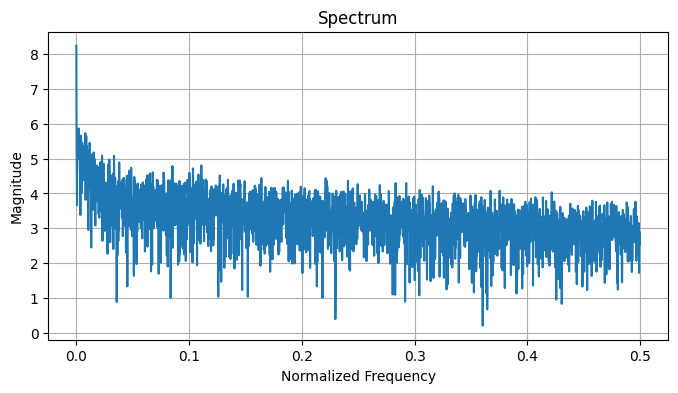

In [16]:
freq, spec = trace_to_log_spectrum(keys[0])

plt.figure(figsize=(8,4))
plt.plot(freq, spec)
plt.xlabel("Normalized Frequency")
plt.ylabel("Magnitude")
plt.title("Spectrum")
plt.grid(True)
plt.show()

## 转化为频谱均值标准差

In [18]:
import numpy as np

def spectrum_band_stats(trace, remove_padding=True, log_scale=True):
    """
    输入一个 ±1 序列，返回全频、低频、中频、高频
    log 幅度谱的标准差。
    """

    trace = np.asarray(trace, dtype=np.float32)

    if remove_padding:
        trace = trace[trace != 0]

    if len(trace) == 0:
        raise ValueError("Empty trace.")

    fft = np.fft.rfft(trace)

    amp = np.abs(fft)

    if log_scale:
        amp = np.log(amp + 1e-8)

    n = len(amp)

    low_end = n // 3
    mid_end = 2 * n // 3

    means ={
        "all": amp.mean(),
        "low": amp[:low_end].mean(),
        "mid": amp[low_end:mid_end].mean(),
        "high": amp[mid_end:].mean()
    }
    stats = {
        "all": amp.std(),
        "low": amp[:low_end].std(),
        "mid": amp[low_end:mid_end].std(),
        "high": amp[mid_end:].std()
    }

    return means,stats

### 只看单条轨迹在频谱幅度标准差(这不对吧哦哦对的对的)

{'all': 6.430661045600867, 'low': 7.3660616719461, 'mid': 6.271517792515699, 'high': 5.654403672340801}


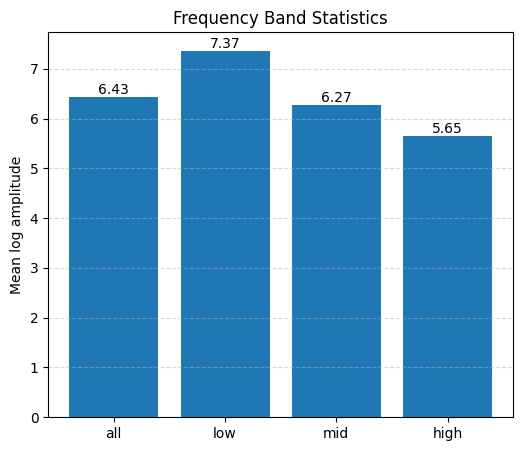

In [24]:
stats = spectrum_band_stats(keys[0])

print(stats)
import matplotlib.pyplot as plt

stats = spectrum_band_stats(keys[0])

labels = list(stats.keys())
values = list(stats.values())

plt.figure(figsize=(6,5))
bars = plt.bar(labels, values)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y,
             f"{y:.2f}",
             ha="center",
             va="bottom")

plt.ylabel("Mean log amplitude")
plt.title("Frequency Band Statistics")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 看某个类的增强轨迹在频谱幅度的标准差

In [10]:
clsmax = 100

for cls in range(clsmax):
    print(f"Start class {cls}", flush=True)
    keys_cls = keys[np.array(labels) == cls]

    stats_list = []

    for trace in keys_cls:
        try:
            stats_list.append(spectrum_band_stats(trace))
        except ValueError:
            continue

    stats = {
        k: np.mean([s[k] for s in stats_list])
        for k in ["all", "low", "mid", "high"]
    }

    print(f"Class {cls}: {len(stats_list)} samples | {stats}")

Start class 0
Class 0: 4996 samples | {'all': 1.4831086846714554, 'low': 1.491272265727774, 'mid': 1.420745411748769, 'high': 1.4083536182194312}
Start class 1
Class 1: 4996 samples | {'all': 1.4739212966713835, 'low': 1.4896314036439633, 'mid': 1.411829457689405, 'high': 1.4035884839898187}
Start class 2
Class 2: 4996 samples | {'all': 1.5835402097339286, 'low': 1.5788740291867036, 'mid': 1.4441961703127222, 'high': 1.5177277050310412}
Start class 3
Class 3: 4996 samples | {'all': 1.5028211983710384, 'low': 1.5118718703329679, 'mid': 1.4346117577232416, 'high': 1.423759028401197}
Start class 4
Class 4: 4996 samples | {'all': 1.465315962082767, 'low': 1.476610419693466, 'mid': 1.401401199469249, 'high': 1.3932275713600712}
Start class 5
Class 5: 4996 samples | {'all': 1.4784717380686176, 'low': 1.4987493438191788, 'mid': 1.4057884773459925, 'high': 1.395406378391648}
Start class 6
Class 6: 4996 samples | {'all': 1.581167023253603, 'low': 1.5465062356471178, 'mid': 1.446952055770619, 'h

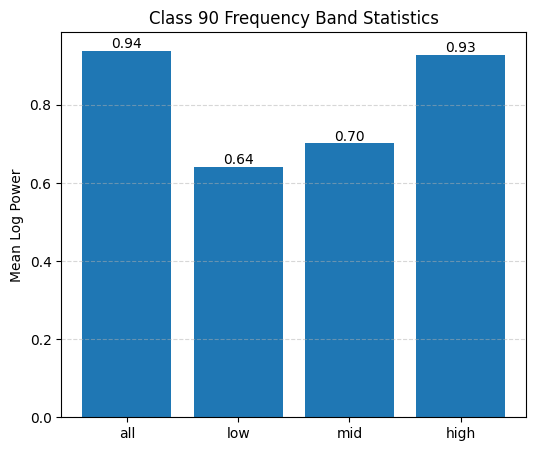

In [27]:
## 之前单个类的作图，已废
import matplotlib.pyplot as plt

labels_name = list(stats.keys())
values = list(stats.values())

plt.figure(figsize=(6,5))
bars = plt.bar(labels_name, values)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             y,
             f"{y:.2f}",
             ha="center",
             va="bottom")

plt.ylabel("Mean Log Power")
plt.title(f"Class {cls} Frequency Band Statistics")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [30]:
## 增强的流量有空值
empty = []

for i, trace in enumerate(keys):
    if np.count_nonzero(trace) == 0:
        empty.append(i)

print(len(empty))
print(empty[:20])

47
[150048, 150246, 150337, 150575, 150604, 150720, 150769, 150834, 151127, 151179, 151460, 151508, 151622, 151660, 151699, 151732, 151737, 151754, 151770, 151771]


### 看看原始的流量的某个类的标准差

In [14]:
clsmax = 102

for cls in range(clsmax):
    print(f"Start class {cls}", flush=True)
    keys_cls = source_feature[np.array(source_label) == cls]

    stats_list = []

    for trace in keys_cls:
        try:
            stats_list.append(spectrum_band_stats(trace))
        except ValueError:
            continue

    stats = {
        k: np.mean([s[k] for s in stats_list])
        for k in ["all", "low", "mid", "high"]
    }

    print(f"Class {cls}: {len(stats_list)} samples | {stats}")

Start class 0
Class 0: 194 samples | {'all': 0.6940476088320746, 'low': 0.7393242706892926, 'mid': 0.6414795467011581, 'high': 0.661869554233197}
Start class 1
Class 1: 193 samples | {'all': 0.6935495396394527, 'low': 0.7512099354875826, 'mid': 0.6361523749195775, 'high': 0.6480461566198882}
Start class 2
Class 2: 184 samples | {'all': 0.6674670745713527, 'low': 0.7065814951183335, 'mid': 0.6383084863255637, 'high': 0.6397569041473108}
Start class 3
Class 3: 165 samples | {'all': 0.6886578556593489, 'low': 0.7273053970812949, 'mid': 0.6450217323931666, 'high': 0.6634252703785668}
Start class 4
Class 4: 193 samples | {'all': 0.7568727493469607, 'low': 0.7879263684596853, 'mid': 0.6466493793066966, 'high': 0.7291639654772409}
Start class 5
Class 5: 196 samples | {'all': 0.6961388047224674, 'low': 0.7618340149525826, 'mid': 0.6393373514971363, 'high': 0.6491728550729549}
Start class 6
Class 6: 193 samples | {'all': 0.7042573295845945, 'low': 0.7174917376731201, 'mid': 0.6291677404112808, 

### 查看目标域day90的

In [6]:
clsmax = 102

for cls in range(clsmax):
    print(f"Start class {cls}", flush=True)
    keys_cls = target_feature[np.array(target_label) == cls]

    stats_list = []

    for trace in keys_cls:
        try:
            stats_list.append(spectrum_band_stats(trace))
        except ValueError:
            continue

    stats = {
        k: np.mean([s[k] for s in stats_list])
        for k in ["all", "low", "mid", "high"]
    }

    print(f"Class {cls}: {len(stats_list)} samples | {stats}")

Start class 0


NameError: name 'target_feature' is not defined

### 查看原始流量到目标流量的平均值差距

In [22]:
clsmax = 102
dataset_delta = {
    "all": [],
    "low": [],
    "mid": [],
    "high": []
}
dataset_relative_delta = {
    "all": [],
    "low": [],
    "mid": [],
    "high": []
}
# 四个频段
bands = ["all", "low", "mid", "high"]
for cls in range(clsmax):
    print(f"Start class {cls}", flush=True)
    source_keys_cls = source_feature[np.array(source_label) == cls]
    target_keys_cls = target_feature[np.array(target_label) == cls]

    source_list = []
    target_list = []

    for trace in source_keys_cls:
        try:
            s_means, _ = spectrum_band_stats(trace)
            source_list.append(s_means)
        except ValueError:
            continue
    for trace in target_keys_cls:
        try:
            t_means, _ = spectrum_band_stats(trace)
            target_list.append(t_means)
        except ValueError:
            continue
    

    source_avg = {}
    target_avg = {}
    delta = {}
    relative_delta = {}
    
    for band in bands:
        source_avg[band] = np.mean([x[band] for x in source_list])
        target_avg[band] = np.mean([x[band] for x in target_list])
        delta[band] = abs(source_avg[band] - target_avg[band])
        relative_delta[band] = (
            abs(source_avg[band]-target_avg[band]) /
            (abs(source_avg[band])+1e-8)
        )
        dataset_delta[band].append(delta[band])
        dataset_relative_delta[band].append(relative_delta[band])
    print(f"Class {cls}")
    print("Source Mean:", source_avg)
    print("Target Mean:", target_avg)
    print("Cross-domain Δ:", delta)

print("\n========== Dataset Statistics ==========")

for band in bands:
    print(
        f"{band:4s}: "
        f"mean Δ = {np.mean(dataset_delta[band]):.6f}, "
        f"std = {np.std(dataset_delta[band]):.6f}",
        f"Relativ = {np.mean(dataset_relative_delta[band]):.4%}"
    )
        

Start class 0
Class 0
Source Mean: {'all': 2.942324884817481, 'low': 3.0190296714876967, 'mid': 2.8125463046179826, 'high': 2.9954500439052603}
Target Mean: {'all': 2.944870593174443, 'low': 3.0259482871379397, 'mid': 2.812221811590672, 'high': 2.9964926811851242}
Cross-domain Δ: {'all': 0.0025457083569624395, 'low': 0.006918615650242987, 'mid': 0.000324493027310524, 'high': 0.0010426372798639783}
Start class 1
Class 1
Source Mean: {'all': 2.76982782866883, 'low': 2.867124506946706, 'mid': 2.6355002121290063, 'high': 2.8070583149949284}
Target Mean: {'all': 2.8093118377701916, 'low': 2.9134049812827123, 'mid': 2.677461602119236, 'high': 2.8371480842088492}
Cross-domain Δ: {'all': 0.03948400910136174, 'low': 0.04628047433600635, 'mid': 0.04196138999022958, 'high': 0.030089769213920814}
Start class 2
Class 2
Source Mean: {'all': 3.4249764633165634, 'low': 3.507915535827102, 'mid': 3.3380092444284135, 'high': 3.4290526534318215}
Target Mean: {'all': 3.449713219176686, 'low': 3.53231366310

# 仅保留不同频段进行分类看看

In [4]:
import numpy as np


def reconstruct_band(trace, band="low", remove_padding=True):
    """
    保留指定频段，其余频率置零，然后IFFT恢复时域。

    Parameters
    ----------
    trace : 1D ndarray
        原始±1方向序列
    band : str
        "low" / "mid" / "high"
    remove_padding : bool
        是否去除0填充

    Returns
    -------
    recon : ndarray(float32)
        重建后的方向序列
    """

    trace = np.asarray(trace, dtype=np.float32)

    if remove_padding:
        trace = trace[trace != 0]

    n_time = len(trace)

    fft = np.fft.rfft(trace)

    n_freq = len(fft)

    low_end = n_freq // 3
    mid_end = 2 * n_freq // 3

    fft_new = np.zeros_like(fft)

    if band == "low":
        fft_new[:low_end] = fft[:low_end]

    elif band == "mid":
        fft_new[low_end:mid_end] = fft[low_end:mid_end]

    elif band == "high":
        fft_new[mid_end:] = fft[mid_end:]

    else:
        raise ValueError("band must be low/mid/high")

    recon = np.fft.irfft(fft_new, n=n_time)

    return recon.astype(np.float32)

In [5]:
low_dataset = []
mid_dataset = []
high_dataset = []

for trace in target_feature:

    low_dataset.append(
        reconstruct_band(trace, "low", remove_padding=False)
    )

    mid_dataset.append(
        reconstruct_band(trace, "mid", remove_padding=False)
    )

    high_dataset.append(
        reconstruct_band(trace, "high", remove_padding=False)
    )

low_dataset = np.asarray(low_dataset, dtype=np.float32)
mid_dataset = np.asarray(mid_dataset, dtype=np.float32)
high_dataset = np.asarray(high_dataset, dtype=np.float32)

In [10]:
# print(low_dataset[0].files)
print(len(low_dataset[1]))
print(len(low_dataset))
print(len(mid_dataset))

10000
28599
28599


In [12]:
np.savez_compressed(
    "protuesday90_low.npz",
    feature=low_dataset,
    label=target_label
)

np.savez_compressed(
    "protuesday90_mid.npz",
    feature=mid_dataset,
    label=target_label
)

np.savez_compressed(
    "protuesday90_high.npz",
    feature=high_dataset,
    label=target_label
)

In [10]:
Mid_data = np.load('protuesday90_mid.npz') 
print(Mid_data.files)
Mid_X = Mid_data['feature']
Mid_Y = Mid_data['label']
print(Mid_X[0])
print(len(Mid_X.shape))

['feature', 'label']
[ 0.07928709 -0.21722694  0.03031064 ...  0.04970084 -0.05994257
  0.01993684]
10000


确实是这样，1-11-11-1这种变化非常剧烈。你把高频删掉以后，这些跳变就不可能存在了。它已经变成了一条平滑曲线。这是低通滤波。实际上很多频域论文就是这么做的，可以接着训练，不要强行变回±1。

### 加上,test,valid的也要保留各自的频段，一般train域valid一致嘛（或者从同一个里面拆出来的）,而test是为了前后输入一致e

# 我们以后还是在portues上做吧，毕竟不同网站一个源域也可以做了主要还是跨时间域的

In [ ]:
#